In [ ]:
!pip install pytorchvideo transformers evaluate torchvision==0.14

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.1/890.1 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 35.7 MB/s eta 0:00

In [ ]:
import os
import warnings

import torch

In [ ]:
base_path = "KLIN/data/raw/KLIN/Anomaly-detection-dataset"
train_file = os.path.join(base_path, "Action_Recognition_splits", "train_full.txt")
test_file = os.path.join(base_path, "Action_Recognition_splits", "test_full.txt")
class_file = os.path.join(base_path, "Action_Recognition_splits", "ClassIDs.txt")
temporal_annotations_file = os.path.join(
    base_path, "Temporal_Anomaly_Annotation_for_Testing_Videos.txt"
)

print("File Class exists:", os.path.exists(class_file))
print("File Train exists:", os.path.exists(train_file))
print("File Test exists:", os.path.exists(test_file))
print("File Temporal exists:", os.path.exists(temporal_annotations_file))

: 

In [ ]:
# Load class mappings
def load_classes(class_file):
    with open(class_file) as f:
        lines = f.read().strip().split("\n")
    # Normalize indices to start from 0
    return {line.split()[0]: int(line.split()[1]) - 1 for line in lines}


def reverse_mapping(class_mapping):
    """
    Create a reverse mapping from IDs to class names.

    Args:
        class_mapping (dict): Mapping of class names to IDs.

    Returns:
        dict: Mapping of IDs to class names.
    """
    return {v: k for k, v in class_mapping.items()}


class_mapping = load_classes(class_file)
reverse_mapping = reverse_mapping(class_mapping)
print(class_mapping)
print(reverse_mapping)

{'Abuse': 0, 'Arrest': 1, 'Arson': 2, 'Assault': 3, 'Burglary': 4, 'Explosion': 5, 'Fighting': 6, 'Normal_Videos_event': 7, 'RoadAccidents': 8, 'Robbery': 9, 'Shooting': 10, 'Shoplifting': 11, 'Stealing': 12, 'Vandalism': 13}
{0: 'Abuse', 1: 'Arrest', 2: 'Arson', 3: 'Assault', 4: 'Burglary', 5: 'Explosion', 6: 'Fighting', 7: 'Normal_Videos_event', 8: 'RoadAccidents', 9: 'Robbery', 10: 'Shooting', 11: 'Shoplifting', 12: 'Stealing', 13: 'Vandalism'}


In [ ]:
import random


# Match video paths with labels
def load_video_label_pairs(split_file, classes):
    video_label_pairs = []
    with open(split_file) as f:
        lines = f.read().strip().split("\n")
    for line in lines:
        label, video_path = line.strip().split("/")
        full_path = os.path.join(
            base_path, "Anomaly_Videos", label + "/" + video_path.strip()
        )
        if os.path.exists(full_path):
            video_label_pairs.append((full_path, {"label": classes[label]}))
        else:
            warnings.warn(f"File not found: {full_path}", stacklevel=1)
    print(f"Total video-label pairs loaded: {len(video_label_pairs)}")  # Debugging
    return video_label_pairs


def split_train_val(video_label_pairs, val_ratio=0.1, seed=None):
    """
    Split video-label pairs into train and val datasets.

    Args:
        video_label_pairs (list): List of video-label pairs.
        val_ratio (float): The ratio of data to be used for valuation.
        seed (int): Random seed for reproducibility.

    Returns:
        tuple: (train_video_label_pairs, val_video_label_pairs)
    """
    if seed is not None:
        random.seed(seed)  # Set the seed for reproducibility

    # Shuffle the dataset
    random.shuffle(video_label_pairs)

    # Calculate the split index
    val_size = int(len(video_label_pairs) * val_ratio)

    # Split the dataset
    val_video_label_pairs = video_label_pairs[:val_size]
    train_video_label_pairs = video_label_pairs[val_size:]

    return train_video_label_pairs, val_video_label_pairs


# Example usage
val_ratio = 0.1  # 10% for valuation
seed = 42  # Set a seed for reproducibility
train_video_label_pairs = load_video_label_pairs(train_file, class_mapping)

train_video_label_pairs, val_video_label_pairs = split_train_val(
    train_video_label_pairs, val_ratio, seed
)
test_video_label_pairs = load_video_label_pairs(test_file, class_mapping)

# Output for verification
print(f"Total train video-label pairs: {len(train_video_label_pairs)}")
print(f"Total val video-label pairs: {len(val_video_label_pairs)}")
print("TRAIN LABEL/PATH: ", train_video_label_pairs[:10])
print("val LABEL/PATH: ", val_video_label_pairs[:10])
print("TEST LABEL/PATH: ", test_video_label_pairs[:10])

<ipython-input-5-ebe9204fee77>:14: UserWarning: File not found: /content/drive/MyDrive/crime_data/Anomaly_Videos/Normal_Videos_event/Normal_Videos_317_x264.mp4
  warnings.warn(f"File not found: {full_path}")
<ipython-input-5-ebe9204fee77>:14: UserWarning: File not found: /content/drive/MyDrive/crime_data/Anomaly_Videos/Normal_Videos_event/Normal_Videos_345_x264.mp4
  warnings.warn(f"File not found: {full_path}")
<ipython-input-5-ebe9204fee77>:14: UserWarning: File not found: /content/drive/MyDrive/crime_data/Anomaly_Videos/Normal_Videos_event/Normal_Videos_352_x264.mp4
  warnings.warn(f"File not found: {full_path}")
<ipython-input-5-ebe9204fee77>:14: UserWarning: File not found: /content/drive/MyDrive/crime_data/Anomaly_Videos/Normal_Videos_event/Normal_Videos_360_x264.mp4
  warnings.warn(f"File not found: {full_path}")
<ipython-input-5-ebe9204fee77>:14: UserWarning: File not found: /content/drive/MyDrive/crime_data/Anomaly_Videos/Normal_Videos_event/Normal_Videos_365_x264.mp4
  warnin

Total video-label pairs loaded: 1976
Total video-label pairs loaded: 624
Total train video-label pairs: 1779
Total val video-label pairs: 197
TRAIN LABEL/PATH:  [('/content/drive/MyDrive/crime_data/Anomaly_Videos/Abuse/Abuse031_x264.mp4', {'label': 0}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/Stealing/Stealing018_x264.mp4', {'label': 12}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/Shoplifting/Shoplifting039_x264.mp4', {'label': 11}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/Shooting/Shooting041_x264.mp4', {'label': 10}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/Arrest/Arrest006_x264.mp4', {'label': 1}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/RoadAccidents/RoadAccidents042_x264.mp4', {'label': 8}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/Stealing/Stealing059_x264.mp4', {'label': 12}), ('/content/drive/MyDrive/crime_data/Anomaly_Videos/RoadAccidents/RoadAccidents017_x264.mp4', {'label': 8}), ('/content/drive/MyDrive/crime_dat

In [ ]:
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor


model_ckpt = "MCG-NJU/videomae-large"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=class_mapping,
    id2label=reverse_mapping,
    ignore_mismatched_sizes=True,
    # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from pytorchvideo.data import LabeledVideoDataset, make_clip_sampler
from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    UniformTemporalSubsample,
)
from torchvision.transforms import (
    Compose,
    Lambda,
    RandomHorizontalFlip,
    Resize,
)

In [ ]:
mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
sample_rate = 800
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

In [ ]:
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    RandomShortSideScale(min_size=256, max_size=320),
                    Resize(resize_to),
                    RandomHorizontalFlip(p=0.5),
                ]
            ),
        ),
    ]
)

val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

In [ ]:
train_dataset = LabeledVideoDataset(
    labeled_video_paths=train_video_label_pairs,
    clip_sampler=make_clip_sampler("random", clip_duration),
    transform=train_transform,
    decode_audio=False,
)

test_dataset = LabeledVideoDataset(
    labeled_video_paths=test_video_label_pairs,
    clip_sampler=make_clip_sampler("uniform", clip_duration),
    transform=val_transform,
    decode_audio=False,
)

val_dataset = LabeledVideoDataset(
    labeled_video_paths=val_video_label_pairs,
    clip_sampler=make_clip_sampler("uniform", clip_duration),
    transform=val_transform,
    decode_audio=False,
)

Video Class: Arrest


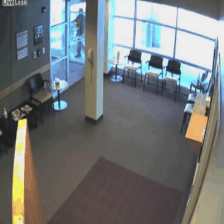

In [ ]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    ...
        The video tensor is expected to have the following shape:
        (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, video_class, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    print(f"Video Class: {reverse_mapping[video_class]}")
    return Image(filename=gif_filename)


sample_video = next(iter(train_dataset))
video_tensor = sample_video["video"]
video_label = sample_video["label"]
display_gif(video_tensor, video_label)

In [ ]:
from transformers import Trainer, TrainingArguments


batch_size = 4
model_name = model_ckpt.split("/")[-1]
new_model_name = f"{model_name}-finetuned-UCF-Crime-dataset"
num_epochs = 30

args = TrainingArguments(
    new_model_name,
    gradient_accumulation_steps=2,
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    fp16=True,
    max_steps=(train_dataset.num_videos // batch_size) * num_epochs,
)

In [ ]:
import evaluate


metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [ ]:
def collate_fn(examples):
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

max_steps is given, it will override any value given in num_train_epochs


In [ ]:
# train_results = trainer.train()

In [ ]:
# TESTING

In [ ]:
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor


# Load the model and processor from Hugging Face
model_name = "pabrcn/videomae-large-finetuned-UCF-Crime-dataset"
model = VideoMAEForVideoClassification.from_pretrained(model_name)
processor = VideoMAEImageProcessor.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/415 [00:00<?, ?B/s]

Video Class: Arrest


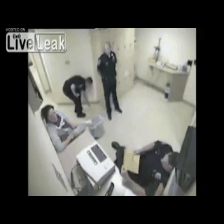

In [ ]:
sample_video = next(iter(test_dataset))
video_tensor = sample_video["video"]
video_label = sample_video["label"]
display_gif(video_tensor, video_label)

In [ ]:
# login to hugging face
from huggingface_hub import login


login()

In [ ]:
# Load the model and processor
model_name = "pabrcn/videomae-large-finetuned-UCF-Crime-dataset"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Reuse the already defined transforms, processor, and datasets
model = VideoMAEForVideoClassification.from_pretrained(
    model_name,
    label2id=class_mapping,
    id2label=reverse_mapping,
    ignore_mismatched_sizes=True,
).to(device)
# print(f"Input tensor shape: {video_tensor.shape}")
# print(model.config)
model.eval()

with torch.no_grad():
    for idx, sample in enumerate(test_dataset):
        video_tensor = sample["video"]
        # Shape: [num_frames, num_channels, height, width]
        label = sample["label"]

        # Adjust tensor shape to match model's expectation
        video_tensor = video_tensor.permute(1, 0, 2, 3).unsqueeze(0).to(device)
        # Shape: [batch_size, num_channels, num_frames, height, width]

        # Forward pass
        outputs = model(video_tensor)

        # Get predictions
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_label = torch.argmax(probs, dim=-1).item()

        print(
            f"Video {idx}: Predicted label = {reverse_mapping[predicted_label]}, "
            f"True label = {reverse_mapping[label]}"
        )

Video 0: Predicted label = Stealing, True label = Stealing
Video 1: Predicted label = Arson, True label = Arson
Video 2: Predicted label = Assault, True label = Assault
Video 3: Predicted label = Explosion, True label = Explosion
Video 4: Predicted label = RoadAccidents, True label = RoadAccidents
Video 5: Predicted label = Vandalism, True label = Vandalism
Video 6: Predicted label = Assault, True label = Assault
Video 7: Predicted label = Arrest, True label = Arrest
Video 8: Predicted label = Arrest, True label = Arrest
Video 9: Predicted label = Arrest, True label = Arrest
Video 10: Predicted label = Arrest, True label = Arrest
Video 11: Predicted label = Burglary, True label = Burglary
Video 12: Predicted label = Arson, True label = Arson
Video 13: Predicted label = Vandalism, True label = Vandalism
Video 14: Predicted label = Burglary, True label = Burglary
Video 15: Predicted label = Stealing, True label = Stealing
Video 16: Predicted label = Arrest, True label = Arrest
Video 17: 